In [1]:
import tensorflow as tf
from tensorflow.keras.datasets.mnist import load_data

In [2]:
(trainx,trainy),(testx,testy)=load_data()

In [3]:
train_images=trainx
train_labels=trainy

In [4]:
train_images.shape

(60000, 28, 28)

In [5]:
train_images=train_images.reshape(train_images.shape[0],28,28,1).astype('float32')

In [6]:
train_images=(train_images-127.5)/127.5

In [7]:
buffer_size=60000
batch_size=256

In [8]:
train_dataset=tf.data.Dataset.from_tensor_slices(train_images).shuffle(buffer_size).batch(batch_size)

In [9]:
from tensorflow.keras import layers

In [10]:
def make_generator_model():
  model=tf.keras.Sequential(name='generator')
  model.add(layers.Dense(7*7*256,use_bias=False,input_shape=(100,)))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())
  model.add(layers.Reshape((7,7,256)))
  model.add(layers.Conv2DTranspose(
      128,(5,5),strides=(2,2),padding='same',use_bias=False
  ))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())
  model.add(layers.Conv2DTranspose(
      64,(5,5),strides=(2,2),padding='same',use_bias=False
  ))
  model.add(layers.BatchNormalization())
  model.add(layers.LeakyReLU())
  model.add(layers.Conv2DTranspose(
      1,(5,5),strides=(1,1),padding='same',use_bias=False,activation='tanh'
  ))
  return model

In [11]:
def make_discriminator_model():
  model=tf.keras.Sequential(name='discriminator')
  model.add(layers.Conv2D(64,(5,5),strides=(2,2),padding='same',input_shape=[28,28,1]))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))
  model.add(layers.Conv2D(128,(5,5),strides=(2,2),padding='same'))
  model.add(layers.LeakyReLU())
  model.add(layers.Dropout(0.3))
  model.add(layers.Flatten())
  model.add(layers.Dense(1,activation='sigmoid'))
  return model

In [12]:
cross_entropy=tf.keras.losses.BinaryCrossentropy(from_logits=True)

In [13]:
def discriminator_loss(real_output,fake_output):
  real_loss=cross_entropy(tf.ones_like(real_output),real_output)
  fake_loss=cross_entropy(tf.zeros_like(fake_output),fake_output)
  return real_loss+fake_loss

def generator_loss(fake_output):
  return cross_entropy(tf.ones_like(fake_output),fake_output)

In [14]:
generator_optimizer=tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer=tf.keras.optimizers.Adam(1e-4)

In [15]:
EPOCHS = 50
noise_dim = 100
num_examples_to_generate = 16

In [16]:
seed=tf.random.normal([num_examples_to_generate,noise_dim])

In [17]:
generator=make_generator_model()
discriminator=make_discriminator_model()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [18]:
@tf.function
def train_step(images):
    noise = tf.random.normal([batch_size, noise_dim])
    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        generated_images = generator(noise, training=True)
        real_output = discriminator(images, training=True)
        fake_output = discriminator(generated_images, training=True)
        gen_loss = generator_loss(fake_output)
        disc_loss = discriminator_loss(real_output, fake_output)
    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)
    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))
    return gen_loss, disc_loss

In [19]:
from IPython import display

In [20]:
gen_losses = []
disc_losses = []

In [21]:
def train(dataset, epochs):
    for epoch in range(epochs):
        epoch_gen_loss = []
        epoch_disc_loss = []

        for image_batch in dataset:
            g_loss, d_loss = train_step(image_batch)
            epoch_gen_loss.append(g_loss)
            epoch_disc_loss.append(d_loss)

        gen_losses.append(tf.reduce_mean(epoch_gen_loss).numpy())
        disc_losses.append(tf.reduce_mean(epoch_disc_loss).numpy())

        display.clear_output(wait=True)
        print(f'Epoch {epoch+1}, Gen Loss: {gen_losses[-1]:.4f}, Disc Loss: {disc_losses[-1]:.4f}')
        generate_and_save_images(generator, epoch+1, seed)

    display.clear_output(wait=True)
    generate_and_save_images(generator, epochs, seed)

In [22]:
import matplotlib.pyplot as plt

def generate_and_save_images(model, epoch, test_input):
    predictions = model(test_input, training=False)

    fig = plt.figure(figsize=(4, 4))

    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i+1)
        plt.imshow(predictions[i, :, :, 0] * 127.5 + 127.5, cmap='gray')
        plt.axis('off')

    plt.savefig('image_at_epoch_{:04d}.png'.format(epoch))
    plt.show()

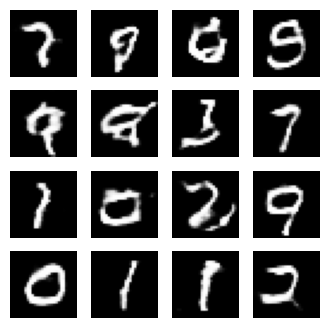

In [23]:
train(train_dataset,EPOCHS)

In [24]:
print(f'gen losses:{gen_losses}')
print(f'dic losses: {disc_losses}')

gen losses:[np.float32(0.9287154), np.float32(0.6665468), np.float32(0.6997011), np.float32(0.7148199), np.float32(0.7482544), np.float32(0.76244414), np.float32(0.74371177), np.float32(0.798903), np.float32(0.7647083), np.float32(0.9045601), np.float32(0.8683718), np.float32(0.83484364), np.float32(0.8580806), np.float32(0.87874377), np.float32(0.8049316), np.float32(0.78081906), np.float32(0.84538144), np.float32(0.83728456), np.float32(0.9105959), np.float32(0.93007743), np.float32(1.0015088), np.float32(1.0329988), np.float32(1.1370907), np.float32(1.0975298), np.float32(1.1399691), np.float32(1.1296349), np.float32(1.0751185), np.float32(1.0207416), np.float32(0.99998456), np.float32(0.9802505), np.float32(0.95257425), np.float32(0.9312788), np.float32(0.91510403), np.float32(1.1676503), np.float32(1.1688002), np.float32(0.9468581), np.float32(0.9371213), np.float32(0.90978074), np.float32(0.8799143), np.float32(0.8936759), np.float32(0.9435919), np.float32(0.89798605), np.float32

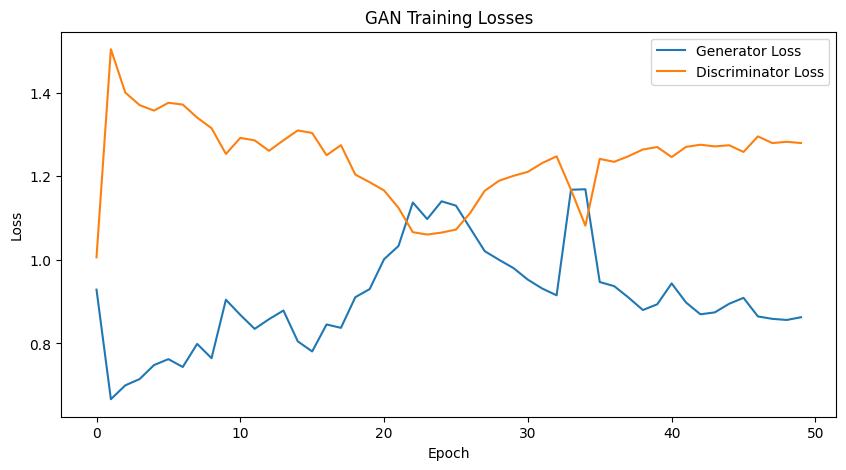

In [25]:
plt.figure(figsize=(10, 5))
plt.plot(gen_losses, label='Generator Loss')
plt.plot(disc_losses, label='Discriminator Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('GAN Training Losses')
plt.legend()
plt.savefig('loss_plot.png')
plt.show()

In [26]:
import glob
import imageio

def create_gif():
    filenames = glob.glob('image_at_epoch_*.png')
    filenames = sorted(filenames)
    frames = []
    for filename in filenames:
        frames.append(imageio.imread(filename))
    imageio.mimsave('gan_training.gif', frames, fps=5)
    print("GIF saved as gan_training.gif")

create_gif()

/tmp/ipykernel_26892/1202301556.py:9: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  frames.append(imageio.imread(filename))


GIF saved as gan_training.gif


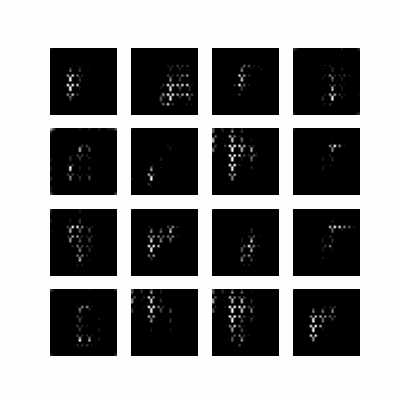

In [27]:
from IPython.display import Image as IPImage, display as IPdisplay

IPdisplay(IPImage(open('gan_training.gif', 'rb').read()))

In [28]:
pip install tensorflow-gan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 367.1/367.1 kB 10.2 MB/s eta 0:00:00


In [31]:
from scipy import linalg
import numpy as np

def calculate_fid(real_images, fake_images):
    # Flatten images
    real_images = real_images.reshape(len(real_images), -1).astype('float32')
    fake_images = fake_images.reshape(len(fake_images), -1).astype('float32')

    # Calculate mean and covariance
    mu_real = np.mean(real_images, axis=0)
    mu_fake = np.mean(fake_images, axis=0)

    sigma_real = np.cov(real_images, rowvar=False)
    sigma_fake = np.cov(fake_images, rowvar=False)

    # FID formula
    diff = mu_real - mu_fake
    covmean = linalg.sqrtm(sigma_real.dot(sigma_fake))

    if np.iscomplexobj(covmean):
        covmean = covmean.real

    fid = diff.dot(diff) + np.trace(sigma_real + sigma_fake - 2 * covmean)
    return fid

# Generate fake images
num_samples = 5000
noise = tf.random.normal([num_samples, noise_dim])
fake_images = generator(noise, training=False).numpy()

# Get real images
real_images = train_images[:num_samples]

fid_score = calculate_fid(real_images, fake_images)
print(f'FID Score: {fid_score:.2f}')
print('(Lower is better. Good MNIST GANs score between 10-30)')

FID Score: 17.71
(Lower is better. Good MNIST GANs score between 10-30)


/tmp/ipykernel_26892/553873801.py:18: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean = linalg.sqrtm(sigma_real.dot(sigma_fake))
